In [16]:
# Imports
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt



Define the Lorenz 63 Drift Function


In [17]:
def drift_l63(x, sigma=10.0, rho=28.0, beta=8.0/3.0):
    """Lorenz '63 drift function."""
    x1, x2, x3 = x
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return jnp.array([dx1, dx2, dx3])

true_drift = lambda x: drift_l63(x) # Correctly-Specified model
slightly_bad_drift = lambda x: drift_l63(x, sigma=11.0) # Slightly Mis-Specified model
very_bad_drift = lambda x: drift_l63(x, sigma=25.0, rho=15.0, beta=10.0) # Highly Mis-Specified model

In [18]:
# System dimensions
state_dim = 3 # Lorenz '63 has 3 state dimensions
emission_dim = 1 # Here we choose to observe only the first dimension
H = jnp.eye(emission_dim, state_dim)

# Noise parameters
diffusion_coeff_true = 1.0
emission_sd_true = 5.0
initial_state_sd_true = 30.0

# Create the SSM
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
from cd_dynamax import ContDiscreteNonlinearGaussianSSM
cdnlgssm = ContDiscreteNonlinearGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)

# Build the true parameters
true_params = cdnlgssm.build_params(
    drift=true_drift,
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

# Build slightly bad parameters for comparison
slightly_bad_params = cdnlgssm.build_params(
    # Use mis-specified drift
    drift=slightly_bad_drift,
    # Keep other parameters the same
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

# Build very bad parameters
very_bad_params = cdnlgssm.build_params(
    # Use mis-specified drift
    drift=very_bad_drift,
    # Keep other parameters the same
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)


Simulate data using true parameters

[make_t_emissions] Generated 100 points from 0.0 to 10.0 with avg step ~0.1000
[make_t_emissions] Smallest time step = 0.002118
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


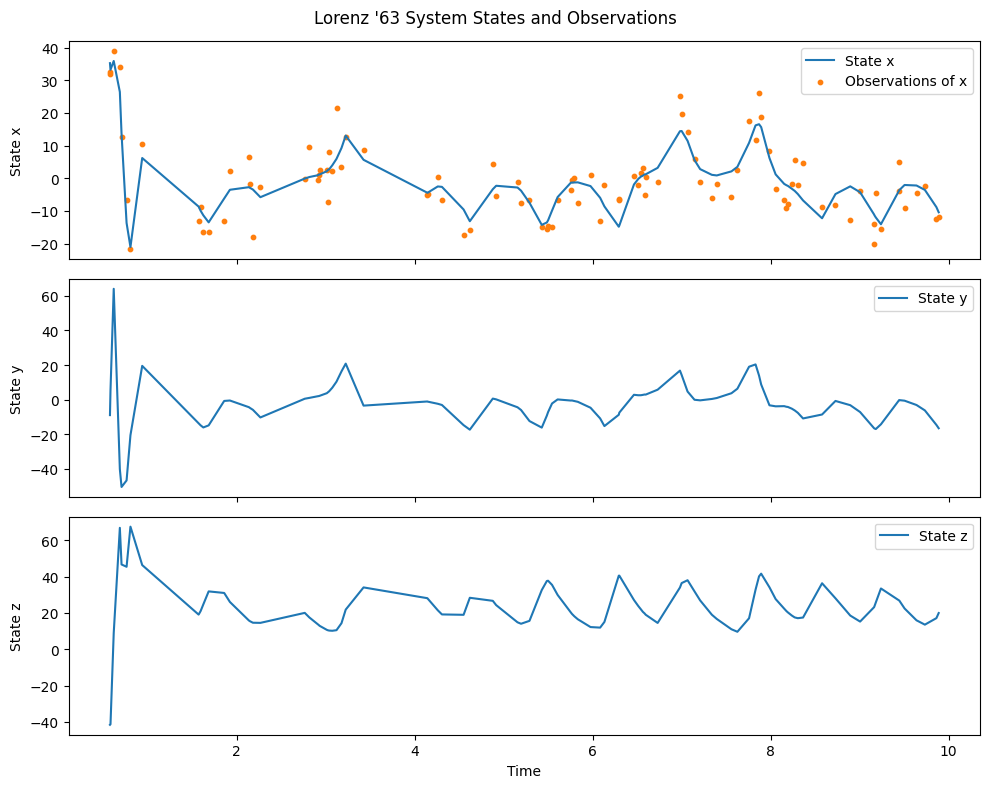

In [19]:
from cd_dynamax import make_key_sequence
from cd_dynamax.src.utils.demo_utils import sample_t_emissions

keys = make_key_sequence(0)
t_emissions = sample_t_emissions(start=0.0, stop=10.0, dt=0.1, regular=False, key=next(keys))

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ['x', 'y', 'z']
for i in range(state_dim):
    axs[i].plot(t_emissions, states[:, i], label=f'State {state_labels[i]}', color='C0')
    if i < emission_dim:
        axs[i].scatter(t_emissions, emissions[:, i], label=f'Observations of {state_labels[i]}', color='C1', s=10)
    axs[i].legend()
    axs[i].set_ylabel(f'State {state_labels[i]}')
axs[-1].set_xlabel('Time')
plt.suptitle('Lorenz \'63 System States and Observations')
plt.tight_layout()
plt.show()

Now perform filtering over the observed emissions using EnKF. This produces filtered state estimates at the observation times, but also, crucially, computes an estimate of the log likelihood of the observed data under the model.

In [20]:
def filter_and_compute_loglik(params, title="True parameters"):
    # Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
    filtered = cdnlgssm.filter(
        params=params,
        emissions=emissions,
        t_emissions=t_emissions,
        key=next(keys),
        N_particles=100,
    )

    print(f"Log likelihood {title}:", float(filtered.marginal_loglik))

    # Plot a subfigure with state_dim rows showing true state, filtered mean and (optionally via shaded region) filtered stddev.
    # Also plot the observations in the first emission_dim rows.
    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
    for i in range(state_dim):
        axs[i].plot(t_emissions, states[:, i], label=f'True State {state_labels[i]}', color='C0')
        axs[i].plot(t_emissions, filtered.filtered_means[:, i], label=f'Filtered Mean {state_labels[i]}', color='C1')
        axs[i].fill_between(
            t_emissions.squeeze(),
            filtered.filtered_means[:, i] - 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            filtered.filtered_means[:, i] + 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            color='C1',
            alpha=0.3,
            label=f'Filtered ±2 Stddev {state_labels[i]}'
        )
        if i < emission_dim:
            axs[i].scatter(t_emissions, emissions[:, i], label=f'Observations of {state_labels[i]}', color='C2', s=10)
        axs[i].legend(loc='upper right')
        axs[i].set_ylabel(f'State {state_labels[i]}')
    axs[-1].set_xlabel('Time')
    plt.suptitle(title)
    plt.tight_layout()

    return filtered.marginal_loglik
        

Now we can compute the log likelihood at the true parameters, then at the mis-specified parameters. We will visualize the resulting filtering distributions as well to give intuitition for why the log likelihoods differ. 

The likelihood should decrease when the parameters get further from the truth---the true parameters should yield the highest log-likelihood. If they don't, then the finite-amount of noisy data is at likely play---those two models are not distinguishable given the data. This is typically why we use Bayesian methods to quantify uncertainty in parameter estimates.

CAVEAT: the likelihood approximation is stochastic and approximate.

Log likelihood Filtering Results at True Parameters: -345.20452574716103
Log likelihood Filtering Results at Slightly Bad Parameters: -355.61611022317265
Log likelihood Filtering Results at Very Bad Parameters: -617.4486799110358
These should be in descending order---the true parameters should yield the highest log-likelihood. 
If they don't, then the finite-amount of noisy data is at play---those two models are not distinguishable given the data.
 CAVEAT: the likelihood approximation is stochastic and approximate.


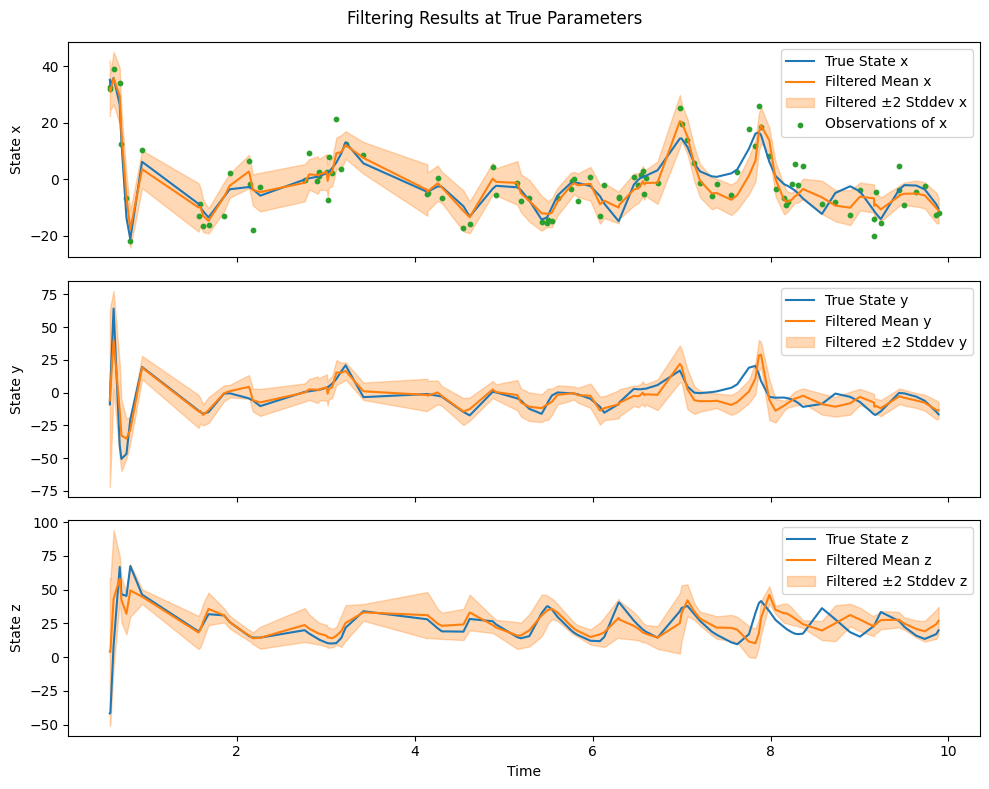

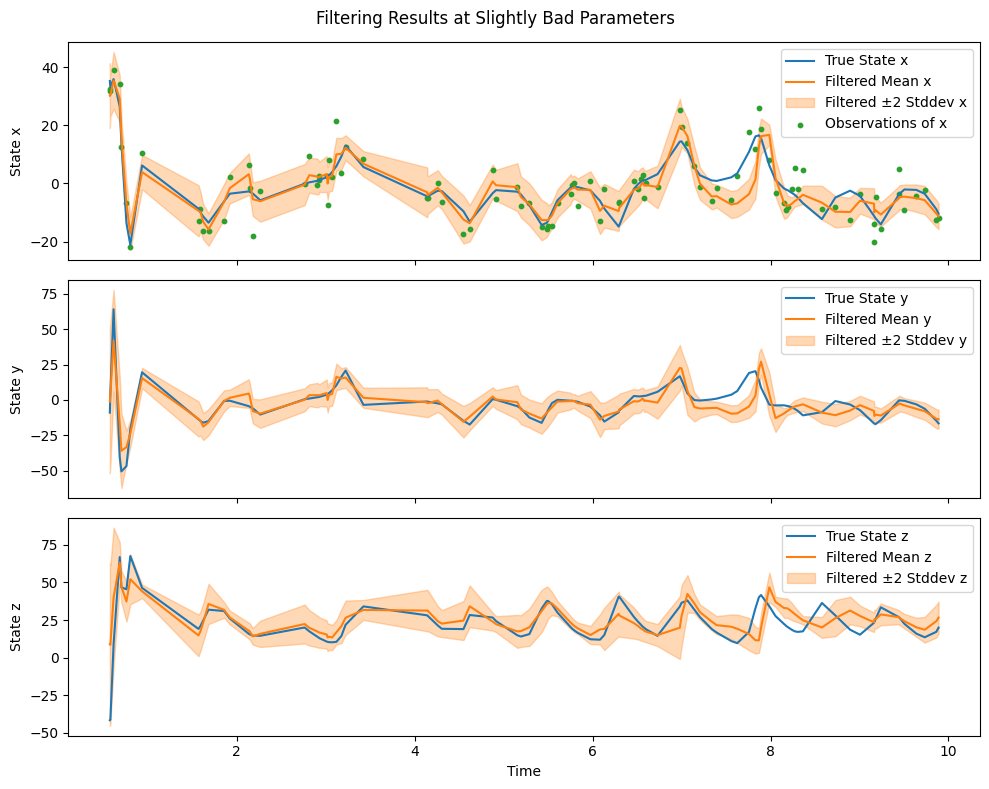

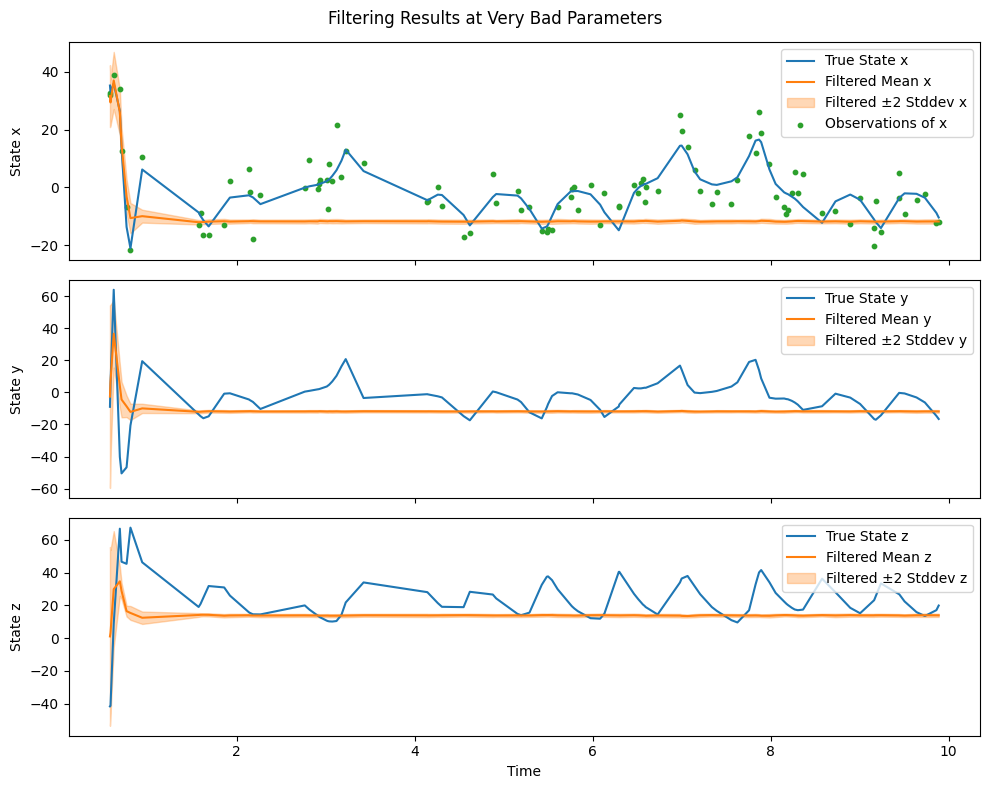

In [ ]:
filter_and_compute_loglik(true_params, title="Filtering Results at True Parameters")
filter_and_compute_loglik(slightly_bad_params, title="Filtering Results at Slightly Bad Parameters")
filter_and_compute_loglik(very_bad_params, title="Filtering Results at Very Bad Parameters")